
# Cybersecurity Dataset: MLP Architecture Search (scikit-learn only)

This notebook searches for a good **Multi-Layer Perceptron (MLP)** architecture on the attached cybersecurity dataset by trying:

- different **numbers of hidden layers**
- different **numbers of perceptrons (neurons) per layer**

It uses **Python packages only** and **does not use PyTorch or TensorFlow**.

## Packages used
- `pandas`
- `numpy`
- `matplotlib`
- `scikit-learn`
- `joblib`

The model selection criterion is mainly **validation macro F1-score**, which is useful when the classes are imbalanced.


In [ ]:

# Uncomment this if you need to install packages locally
# !pip install pandas numpy matplotlib scikit-learn joblib


In [1]:

import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (10, 5)



## 1. Load the dataset

The notebook first tries to load `cyber_15000.csv` from the current folder.  
If that is not found, it falls back to `/mnt/data/cyber_15000.csv`.


In [2]:

possible_paths = [
    Path("cyber_15000.csv"),
    Path("cyber_15000.csv"),
]

dataset_path = None
for p in possible_paths:
    if p.exists():
        dataset_path = p
        break

if dataset_path is None:
    raise FileNotFoundError("Could not find cyber_15000.csv in the working directory or /mnt/data/")

df = pd.read_csv(dataset_path)
print(f"Loaded dataset from: {dataset_path}")
print(f"Shape: {df.shape}")
df.head()


Loaded dataset from: cyber_15000.csv
Shape: (6673, 362)


/tmp/ipykernel_250/4006862430.py:15: DtypeWarning: Columns (352,353,354,355,356,357,358) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dataset_path)


,record_id,timestamp_utc,flow_duration_ms,bytes_out,bytes_in,pkts_out,pkts_in,unique_dst_ips,unique_dst_ports,dst_port_entropy,...,protocol_ICMP,protocol_TCP,protocol_UDP,device_iot,device_mobile,device_server,device_workstation,incident_impact_score,attack_type,timestamp_min_since_2026_01_01
0,0,2026-01-16 03:41:00,0.009266,7.530496,4.299825,12.108840,0.955393,31.0,39.0,-4.734544,...,False,True,False,False,False,False,True,78.548744,malware,21821.0
1,1,2026-01-31 03:23:00,0.045512,3.396149,0.217386,-0.087921,-0.207385,25.0,0.0,-1.714563,...,False,True,False,False,False,False,True,29.234982,benign,43403.0
2,2,2026-01-23 12:51:00,1.419946,3.373238,3.218698,2.735832,0.145083,0.0,30.0,-2.575859,...,False,True,False,False,False,False,True,41.989082,ddos,32451.0
3,3,2026-01-06 02:23:00,0.270251,1.036632,3.338362,1.594328,-1.405170,25.0,24.0,1.765198,...,False,False,True,False,True,False,False,46.605885,malware,7343.0
4,4,2026-02-04 05:41:00,0.782252,1.165075,1.383776,14.294488,2.267065,0.0,33.0,-0.673965,...,False,True,False,False,False,False,True,30.760412,benign,49301.0


In [3]:

print("Column count:", len(df.columns))
print("\nData types:")
print(df.dtypes.value_counts())
print("\nMissing values:", int(df.isna().sum().sum()))


Column count: 362

Data types:
float64    352
object       9
int64        1
Name: count, dtype: int64

Missing values: 162



## 2. Detect the target column

This notebook prefers `attack_type` as the label column.  
If that column is not present, it falls back to the last categorical column.


In [4]:

preferred_target = "attack_type"

if preferred_target in df.columns:
    target_col = preferred_target
else:
    object_cols = df.select_dtypes(include="object").columns.tolist()
    if not object_cols:
        raise ValueError("Could not detect a target column automatically.")
    target_col = object_cols[-1]

print("Target column:", target_col)
print("\nClass distribution:")
print(df[target_col].value_counts())


Target column: attack_type

Class distribution:
attack_type
benign        3727
phishing       803
malware        764
ddos           687
insider        438
ransomware     253
Name: count, dtype: int64



## 3. Prepare features

For this dataset, the neural network uses **numeric features only**.  
Common identifier/time columns such as `record_id` and raw timestamp strings are dropped when present.


In [5]:

drop_if_present = ["record_id", "timestamp_utc"]
drop_cols = [c for c in drop_if_present if c in df.columns]

X_raw = df.drop(columns=drop_cols + [target_col])
non_numeric_cols = X_raw.select_dtypes(exclude=np.number).columns.tolist()

if non_numeric_cols:
    print("Dropping non-numeric feature columns:", non_numeric_cols)

X = X_raw.select_dtypes(include=np.number).copy()
y = df[target_col].copy()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Final feature matrix shape:", X.shape)
print("Encoded classes:", list(label_encoder.classes_))


Dropping non-numeric feature columns: ['protocol_ICMP', 'protocol_TCP', 'protocol_UDP', 'device_iot', 'device_mobile', 'device_server', 'device_workstation']
Final feature matrix shape: (6673, 352)
Encoded classes: ['benign', 'ddos', 'insider', 'malware', 'phishing', 'ransomware', nan]


## 4. Train / validation / test split

In [8]:
import numpy as np

# First, identify the index of the 'nan' class in label_encoder.classes_
nan_class_index = -1
for idx, class_name in enumerate(label_encoder.classes_):
    if pd.isna(class_name): # Use pd.isna to robustly check for NaN
        nan_class_index = idx
        break

# Filter out samples where y_encoded corresponds to the 'nan' class
if nan_class_index != -1:
    valid_indices = y_encoded != nan_class_index
    X_filtered = X.loc[valid_indices] # Use .loc for DataFrame filtering
    y_encoded_filtered = y_encoded[valid_indices]
    print(f"Removed {len(y_encoded) - len(y_encoded_filtered)} samples corresponding to the 'nan' class (index {nan_class_index}).")
    print("Class distribution after filtering for NaN:")
    print(pd.Series(y_encoded_filtered).value_counts().sort_index())
else:
    X_filtered = X
    y_encoded_filtered = y_encoded
    print("No NaN class found to filter.")

# Now perform the train_test_split on the filtered data
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_filtered, y_encoded_filtered,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_encoded_filtered
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_trainval
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Removed 1 samples corresponding to the 'nan' class (index 6).
Class distribution after filtering for NaN:
0    3727
1     687
2     438
3     764
4     803
5     253
Name: count, dtype: int64
Train shape: (4269, 352)
Validation shape: (1068, 352)
Test shape: (1335, 352)



## 5. Define candidate architectures

Each tuple below represents the hidden-layer structure:

- `(64,)` means **1 hidden layer with 64 neurons**
- `(128, 64)` means **2 hidden layers with 128 and 64 neurons**
- `(128, 64, 32)` means **3 hidden layers**


In [9]:

architecture_grid = [
    (32,),
    (64,),
    (128,),
    (256,),
    (64, 32),
    (128, 64),
    (128, 128),
    (256, 128),
    (128, 64, 32),
    (256, 128, 64),
    (128, 128, 64),
    (256, 128, 128),
]

architecture_grid


[(32,),
 (64,),
 (128,),
 (256,),
 (64, 32),
 (128, 64),
 (128, 128),
 (256, 128),
 (128, 64, 32),
 (256, 128, 64),
 (128, 128, 64),
 (256, 128, 128)]


## 6. Train and compare the MLP models

The search keeps most hyperparameters fixed and changes the architecture only.  
Selection is based on:

1. **Validation macro F1-score**
2. Validation accuracy


In [10]:

results = []

for arch in architecture_grid:
    print(f"Training architecture: {arch}")
    start_time = time.time()

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=arch,
            activation="relu",
            solver="adam",
            alpha=1e-4,
            batch_size=256,
            learning_rate_init=1e-3,
            max_iter=80,
            early_stopping=True,
            validation_fraction=0.10,
            n_iter_no_change=8,
            random_state=RANDOM_STATE
        ))
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    mlp = model.named_steps["mlp"]

    results.append({
        "architecture": str(arch),
        "num_hidden_layers": len(arch),
        "train_accuracy": accuracy_score(y_train, train_pred),
        "val_accuracy": accuracy_score(y_val, val_pred),
        "val_macro_f1": f1_score(y_val, val_pred, average="macro"),
        "val_weighted_f1": f1_score(y_val, val_pred, average="weighted"),
        "epochs_run": mlp.n_iter_,
        "fit_time_sec": time.time() - start_time
    })

results_df = pd.DataFrame(results).sort_values(
    by=["val_macro_f1", "val_accuracy"],
    ascending=False
).reset_index(drop=True)

results_df


Training architecture: (32,)
Training architecture: (64,)
Training architecture: (128,)
Training architecture: (256,)
Training architecture: (64, 32)
Training architecture: (128, 64)
Training architecture: (128, 128)
Training architecture: (256, 128)
Training architecture: (128, 64, 32)
Training architecture: (256, 128, 64)
Training architecture: (128, 128, 64)
Training architecture: (256, 128, 128)


,architecture,num_hidden_layers,train_accuracy,val_accuracy,val_macro_f1,val_weighted_f1,epochs_run,fit_time_sec
0,"(128, 128, 64)",3,0.845397,0.675094,0.526964,0.660152,17,4.157828
1,"(128,)",1,0.816350,0.669476,0.515799,0.657592,19,1.383534
2,"(128, 64, 32)",3,0.834856,0.663858,0.510658,0.653567,20,2.028254
3,"(256,)",1,0.958538,0.677903,0.510305,0.663297,43,5.573811
4,"(64,)",1,0.811197,0.670412,0.507864,0.655264,26,1.482059
5,"(256, 128, 128)",3,0.923870,0.682584,0.506997,0.666905,18,4.777586
6,"(128, 128)",2,0.779339,0.679775,0.499990,0.659461,15,3.340613
7,"(256, 128)",2,0.815179,0.664794,0.495708,0.638996,15,2.771588
8,"(128, 64)",2,0.808855,0.668539,0.471396,0.644274,18,2.938911
9,"(256, 128, 64)",3,0.767627,0.665730,0.461694,0.634127,13,2.593910


In [11]:

print("Top architectures:")
results_df.head(10)


Top architectures:


,architecture,num_hidden_layers,train_accuracy,val_accuracy,val_macro_f1,val_weighted_f1,epochs_run,fit_time_sec
0,"(128, 128, 64)",3,0.845397,0.675094,0.526964,0.660152,17,4.157828
1,"(128,)",1,0.816350,0.669476,0.515799,0.657592,19,1.383534
2,"(128, 64, 32)",3,0.834856,0.663858,0.510658,0.653567,20,2.028254
3,"(256,)",1,0.958538,0.677903,0.510305,0.663297,43,5.573811
4,"(64,)",1,0.811197,0.670412,0.507864,0.655264,26,1.482059
5,"(256, 128, 128)",3,0.923870,0.682584,0.506997,0.666905,18,4.777586
6,"(128, 128)",2,0.779339,0.679775,0.499990,0.659461,15,3.340613
7,"(256, 128)",2,0.815179,0.664794,0.495708,0.638996,15,2.771588
8,"(128, 64)",2,0.808855,0.668539,0.471396,0.644274,18,2.938911
9,"(256, 128, 64)",3,0.767627,0.665730,0.461694,0.634127,13,2.593910


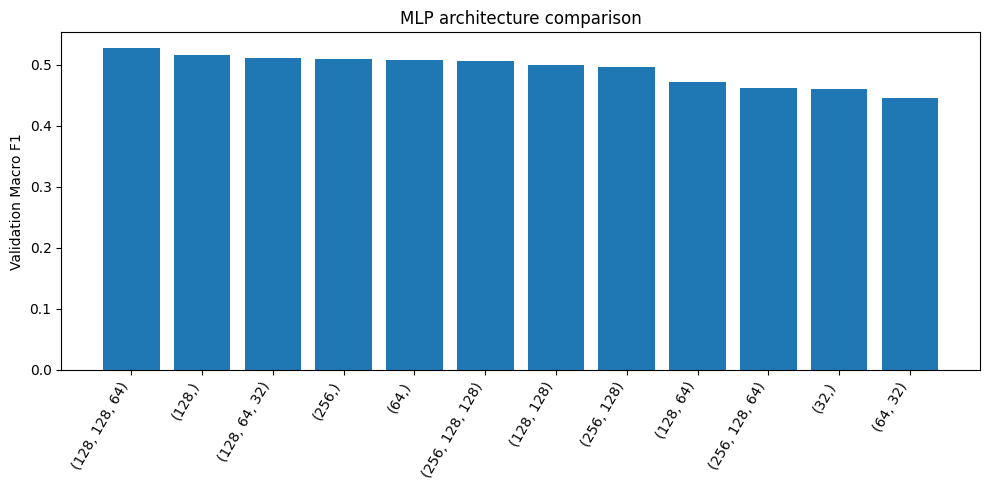

In [12]:

plt.figure()
plt.bar(results_df["architecture"], results_df["val_macro_f1"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("Validation Macro F1")
plt.title("MLP architecture comparison")
plt.tight_layout()
plt.show()


## 7. Retrain the best architecture on train + validation data

In [13]:

best_arch_str = results_df.loc[0, "architecture"]
best_arch = eval(best_arch_str)

print("Best architecture found:", best_arch)
print("Best validation macro F1:", results_df.loc[0, "val_macro_f1"])
print("Best validation accuracy:", results_df.loc[0, "val_accuracy"])


Best architecture found: (128, 128, 64)
Best validation macro F1: 0.5269637059852099
Best validation accuracy: 0.6750936329588015


In [14]:

X_best_train = pd.concat([X_train, X_val], axis=0)
y_best_train = np.concatenate([y_train, y_val])

best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=best_arch,
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=256,
        learning_rate_init=1e-3,
        max_iter=120,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=10,
        random_state=RANDOM_STATE
    ))
])

best_model.fit(X_best_train, y_best_train)
test_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, test_pred)
test_macro_f1 = f1_score(y_test, test_pred, average="macro")
test_weighted_f1 = f1_score(y_test, test_pred, average="weighted")

print("Test accuracy:", test_accuracy)
print("Test macro F1:", test_macro_f1)
print("Test weighted F1:", test_weighted_f1)


Test accuracy: 0.6831460674157304
Test macro F1: 0.5305626182484077
Test weighted F1: 0.677236837764954


In [16]:
import pandas as pd # Ensure pandas is imported for pd.isna()

# Filter out the 'nan' class from label_encoder.classes_ for target_names
filtered_target_names = [name for name in label_encoder.classes_ if not pd.isna(name)]

print(classification_report(
    y_test,
    test_pred,
    target_names=filtered_target_names
))


              precision    recall  f1-score   support

      benign       0.81      0.85      0.83       746
        ddos       0.61      0.54      0.57       137
     insider       0.58      0.56      0.57        88
     malware       0.44      0.48      0.46       153
    phishing       0.48      0.40      0.44       161
  ransomware       0.36      0.28      0.31        50

    accuracy                           0.68      1335
   macro avg       0.55      0.52      0.53      1335
weighted avg       0.67      0.68      0.68      1335



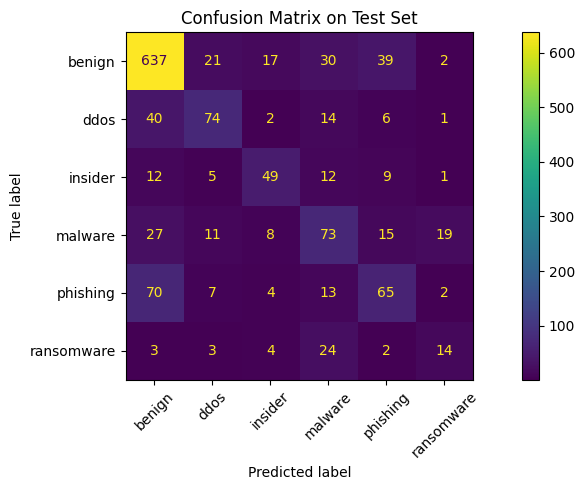

In [18]:
cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=filtered_target_names)
disp.plot(values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix on Test Set")
plt.tight_layout()
plt.show()


## 8. Save the results and the best model

In [19]:

results_df.to_csv("mlp_architecture_search_results.csv", index=False)
joblib.dump(best_model, "best_mlp_cyber_model.joblib")

print("Saved:")
print("- mlp_architecture_search_results.csv")
print("- best_mlp_cyber_model.joblib")


Saved:
- mlp_architecture_search_results.csv
- best_mlp_cyber_model.joblib



## Notes

- The notebook uses **scikit-learn's `MLPClassifier`**
- It does **not** use PyTorch or TensorFlow
- You can expand `architecture_grid` if you want an even wider search
- If training takes too long on your machine, reduce:
  - `architecture_grid`
  - `max_iter`
  - the largest layer sizes
